# Image Dataset Pipeline — Makanan Indonesia
**Project:** Jivara (CC26-PSU090) | **Role:** Data Science  
**Dataset:** Makanan Indonesia (35 Kelas, 1.643 Gambar)

Dataset ini memiliki format **Image Classification (One-Hot Encoding)**, tidak seperti Roboflow yang menggunakan Bounding Box. Pipeline ini mencakup:
1. Initialization
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Data Wrangling (Pembuatan Bounding Box Sintetis untuk YOLO)
5. Final Report

---
## 1. Initialization

Memuat seluruh library yang diperlukan dan mendefinisikan path direktori.

In [1]:
import pandas as pd
import numpy as np
import os
import cv2
import hashlib
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

BASE_DIR = Path(r'd:\Dicoding Academy\DataCapstone')
RAW_DIR = BASE_DIR / 'data_mentah' / 'makanan_indonesia'
IMAGE_DIR = RAW_DIR / 'food-tfk-images'
OUTPUT_DIR = BASE_DIR / 'data_output' / 'yolo_makanan_indonesia'

# Mapping file split
SPLIT_FILES = {
    'train': 'train.csv',
    'val': 'dev.csv',
    'test': 'test.csv'
}

# Buat direktori output YOLO
for split_name in SPLIT_FILES.keys():
    (OUTPUT_DIR / 'images' / split_name).mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / 'labels' / split_name).mkdir(parents=True, exist_ok=True)

print("Setup direktori selesai.")

Setup direktori selesai.


---
## 2. Exploratory Data Analysis

### 2.1 Load Data dan Dekode One-Hot Labels

Dataset ini menggunakan format one-hot encoding (1 dan 0). Kita perlu mendekodenya menjadi label kelas tunggal per gambar.

In [2]:
def load_and_decode_csv(raw_directory, split_files):
    """Memuat CSV dan mengubah one-hot encoding menjadi single label."""
    dataframes = []
    
    for split_name, filename in split_files.items():
        csv_path = raw_directory / filename
        df = pd.read_csv(csv_path)
        
        # Kolom kelas dimulai dari index ke-3 (setelah Image Index, Patient ID, Finding Labels)
        class_columns = df.columns[3:]
        
        # Ekstrak kelas aktif (nilai == 1)
        # Asumsi: Setiap gambar hanya memiliki 1 makanan utama
        df['active_class'] = df[class_columns].idxmax(axis=1)
        df['split'] = split_name
        
        dataframes.append(df[['Image Index', 'active_class', 'split']])
        
    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df, list(class_columns)

dataset_df, class_names = load_and_decode_csv(RAW_DIR, SPLIT_FILES)

print("=" * 50)
print("RINGKASAN DATASET MAKANAN INDONESIA")
print("=" * 50)
print(f"Total gambar: {len(dataset_df)}")
print(f"Total kelas : {len(class_names)}\n")

for split_name in SPLIT_FILES.keys():
    count = len(dataset_df[dataset_df['split'] == split_name])
    print(f"  {split_name:>5}: {count:>4} gambar")

print(f"\nContoh Kelas: {class_names[:5]}...")

RINGKASAN DATASET MAKANAN INDONESIA
Total gambar: 1643
Total kelas : 35

  train: 1150 gambar
    val:  164 gambar
   test:  329 gambar

Contoh Kelas: ['asinan-jakarta', 'ayam-betutu', 'ayam-bumbu-rujak', 'ayam-goreng-lengkuas', 'bika-ambon']...


### 2.2 Distribusi Kelas

Melihat apakah dataset 35 kelas ini seimbang atau mengalami class imbalance.

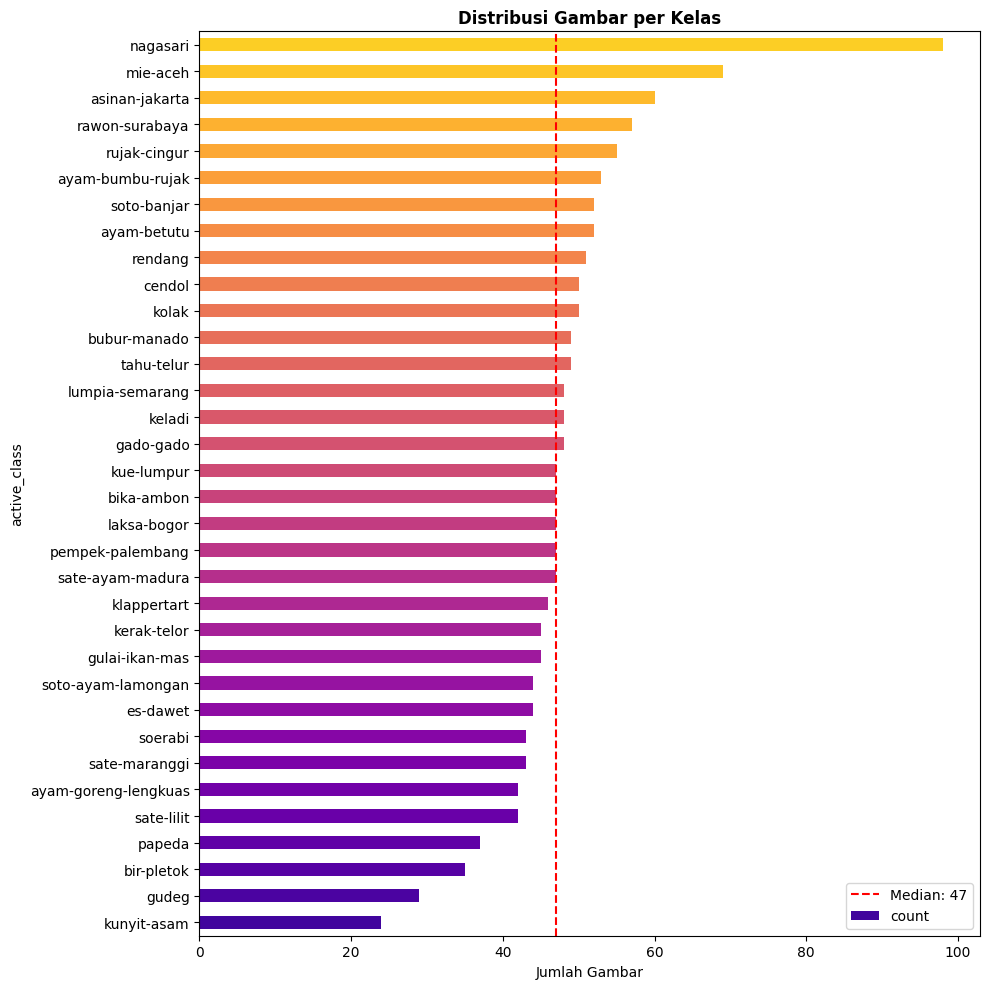

Kelas terbanyak : nagasari (98)
Kelas tersedikit: kunyit-asam (24)
Imbalance ratio : 4.1x


In [3]:
class_counts = dataset_df['active_class'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(class_counts)))

class_counts.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Distribusi Gambar per Kelas', fontweight='bold')
ax.set_xlabel('Jumlah Gambar')
ax.axvline(x=class_counts.median(), color='red', linestyle='--', label=f'Median: {class_counts.median():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Kelas terbanyak : {class_counts.idxmax()} ({class_counts.max()})")
print(f"Kelas tersedikit: {class_counts.idxmin()} ({class_counts.min()})")
print(f"Imbalance ratio : {class_counts.max() / class_counts.min():.1f}x")

---
## 3. Data Cleaning

Memastikan file gambar benar-benar ada di dalam folder `food-tfk-images` dan dapat dibaca.

In [4]:
def validate_image_files(dataframe, image_directory):
    """Periksa keberadaan dan integritas file gambar."""
    missing_files = []
    corrupt_files = []
    valid_count = 0

    for filename in dataframe['Image Index']:
        img_path = image_directory / filename
        
        if not img_path.exists():
            missing_files.append(filename)
            continue
            
        try:
            img = Image.open(img_path)
            img.verify()
            valid_count += 1
        except Exception:
            corrupt_files.append(filename)

    return valid_count, missing_files, corrupt_files

valid_count, missing_files, corrupt_files = validate_image_files(dataset_df, IMAGE_DIR)

print(f"Gambar valid  : {valid_count}")
print(f"File hilang   : {len(missing_files)}")
print(f"File corrupt  : {len(corrupt_files)}")

# Filter dataframe jika ada yang hilang/corrupt
invalid_files = set(missing_files + corrupt_files)
if invalid_files:
    dataset_clean = dataset_df[~dataset_df['Image Index'].isin(invalid_files)].copy()
else:
    dataset_clean = dataset_df.copy()

Gambar valid  : 1643
File hilang   : 0
File corrupt  : 0


---
## 4. Data Wrangling — Sintesis Bounding Box YOLO

Karena target model kita adalah Object Detection (YOLOv11), dataset ini tidak memiliki bounding box.  
Kita akan membuat **Synthetic Bounding Box (Full Frame 90%)**.

**Format YOLO:** `class_id x_center y_center width height`  
**Sintetis 90%:** `class_id 0.500000 0.500000 0.900000 0.900000`

In [5]:
# Buat pemetaan kelas ke ID numerik
class_to_id = {name: idx for idx, name in enumerate(class_names)}

def create_synthetic_yolo_dataset(dataframe, source_img_dir, output_dir, class_mapping):
    """Menyalin gambar dan membuat label YOLO sintetis (90% frame)."""
    import shutil
    
    # Koordinat sintetis (Tengah gambar, lebar 90%, tinggi 90%)
    X_CENTER, Y_CENTER = 0.5, 0.5
    B_WIDTH, B_HEIGHT = 0.9, 0.9
    
    total_processed = 0
    
    for _, row in dataframe.iterrows():
        filename = row['Image Index']
        split_name = row['split']
        class_name = row['active_class']
        class_id = class_mapping[class_name]
        
        source_img = source_img_dir / filename
        dest_img = output_dir / 'images' / split_name / filename
        dest_lbl = output_dir / 'labels' / split_name / (Path(filename).stem + '.txt')
        
        # Copy gambar
        if not dest_img.exists():
            shutil.copy2(source_img, dest_img)
            
        # Buat label TXT
        label_content = f"{class_id} {X_CENTER:.6f} {Y_CENTER:.6f} {B_WIDTH:.6f} {B_HEIGHT:.6f}\n"
        with open(dest_lbl, 'w') as f:
            f.write(label_content)
            
        total_processed += 1
        
    print(f"Berhasil memproses {total_processed} gambar ke format YOLO.")

create_synthetic_yolo_dataset(dataset_clean, IMAGE_DIR, OUTPUT_DIR, class_to_id)

Berhasil memproses 1643 gambar ke format YOLO.


### 4.2 Generate `data.yaml`

In [6]:
import yaml

data_config = {
    'path': str(OUTPUT_DIR),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': len(class_names),
    'names': class_names
}

yaml_path = OUTPUT_DIR / 'data.yaml'
with open(yaml_path, 'w') as file_handle:
    yaml.dump(data_config, file_handle, default_flow_style=False, sort_keys=False)

print(f"File konfigurasi tersimpan: {yaml_path}")

File konfigurasi tersimpan: d:\Dicoding Academy\DataCapstone\data_output\yolo_makanan_indonesia\data.yaml


---
## 5. Visual Check

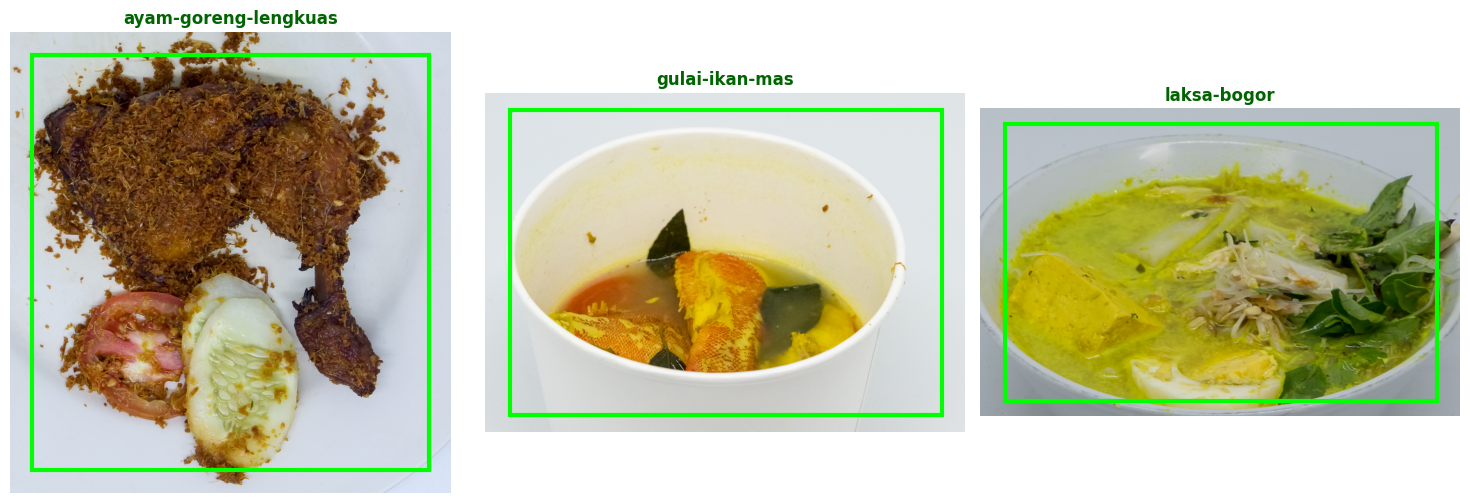

In [7]:
import matplotlib.patches as patches

def plot_synthetic_samples(output_dir, class_names, sample_count=3):
    """Menampilkan gambar dengan bounding box sintetis."""
    image_dir = output_dir / 'images' / 'train'
    label_dir = output_dir / 'labels' / 'train'
    image_files = list(image_dir.glob('*.jpg'))
    
    np.random.seed(12)
    samples = np.random.choice(image_files, min(sample_count, len(image_files)), replace=False)
    
    fig, axes = plt.subplots(1, sample_count, figsize=(5 * sample_count, 5))
    if sample_count == 1: axes = [axes]
        
    for idx, image_path in enumerate(samples):
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_height, img_width = image.shape[:2]
        
        axes[idx].imshow(image)
        
        label_path = label_dir / (image_path.stem + '.txt')
        if label_path.exists():
            with open(label_path) as fh:
                parts = fh.readline().strip().split()
                class_id = int(parts[0])
                x_c, y_c, b_w, b_h = [float(v) for v in parts[1:]]

                # Denormalize
                x1 = (x_c - b_w / 2) * img_width
                y1 = (y_c - b_h / 2) * img_height
                box_w = b_w * img_width
                box_h = b_h * img_height

                rect = patches.Rectangle((x1, y1), box_w, box_h, linewidth=3, edgecolor='lime', facecolor='none')
                axes[idx].add_patch(rect)
                axes[idx].set_title(class_names[class_id], fontsize=12, fontweight='bold', color='darkgreen')
                
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_synthetic_samples(OUTPUT_DIR, class_names)